# Import mda data loading functions

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import date
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import ticker
import seaborn as sns

import scipy.signal as sps
from scipy.optimize import leastsq
from scipy import integrate

import xraydb
import mda
from larch import Group
from larch.xafs import xftf, pre_edge
from larch.io import read_ascii
from larch_xas import extract_exafs_transmission_frame, flatten_transmission_frame

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
cm = 1 / 2.54

In [ ]:
raw_data_dir = "/media/Computation_bkp/Haoyu_MEX_XAS_20260327/xas_raw_data_20260327"

# plt.style.use(f"{os.environ['JX']}/jx/jlw.mplstyle")
paulTolHighContrast = ['#33bbee', '#cc3311', '#ee3377', '#0077bb', '#ee7733', '#009988']
# blue_gradient = (
#     "#7BC1E0",
#     "#4FA3D1",
#     "#2A7FB8",
#     "#1C5A8A",
#     "#123A63",
#     "#0B1F3A"
# )
sns.set_palette(paulTolHighContrast)

sr570Dict = {
    0 : ('1 pA/V',1.00E+12),
    1 : ('2 pA/V', 5.00E+11),
    2 : ('5 pA/V', 2.00E+11),
    3 : ('10 pA/V', 1.00E+11),
    4 : ('20 pA/V', 5.00E+10),
    5 : ('50 pA/V', 2.00E+10),
    6 : ('100 pA/V', 1.00E+10),
    7 : ('200 pA/V', 5.00E+09),
    8 : ('500 pA/V', 2.00E+09),
    9 : ('1 nA/V', 1.00E+09),
    10 : ('2 nA/V', 5.00E+08),
    11 : ('5 nA/V', 2.00E+08),
    12 : ('10 nA/V', 1.00E+08),
    13 : ('20 nA/V', 5.00E+07),
    14 : ('50 nA/V', 2.00E+07),
    15 : ('100 nA/V', 1.00E+07),
    16 : ('200 nA/V', 5.00E+06),
    17 : ('500 nA/V', 2.00E+06),
    18 : ('1 uA/V', 1.00E+06),
    19 : ('2 uA/V', 5.00E+05),
    20 : ('5 uA/V', 2.00E+05),
    21 : ('10 uA/V', 1.00E+05),
    22 : ('20 uA/V', 5.00E+04),
    23 : ('50 uA/V', 2.00E+04),
    24 : ('100 uA/V', 1.00E+04),
    25 : ('200 uA/V', 5.00E+03),
    26 : ('500 uA/V', 2.00E+03),
    27 : ('1 mA/V', 1.00E+03),
    }


def mdaDetails(theMda):
    '''
    What dimension holds which data?
    Step scans
        0: extra PVs (metadata describing the state of the beamline)
        1: the step scan data
        2: the 4096 energy bin fluoro spectra for each detector element
    Slew scans
        0: extra PVs (metadata describing the state of the beamline)
        1: empty
        2: the slew scan data
        for slew scans, the per-channel fluoro spectra are stored in a hdf5 file with the same scan number in the file name
    '''
    print('This mda has {} dimensions'.format(len(theMda)))
    print('DIMENSION 0 = extraPVs')
    print('There are {} extra PVs'.format(len(theMda[0])))
    print('********************')
    for dim in range(1,len(theMda)):
        print('DIMENSION {} - Positioners'.format(dim))
        if len(theMda[dim].p) == 0:
            print('No positioners for dimension {}'.format(dim))
        else:
            for i in range(0,len(theMda[dim].p)):
                print('positioner {}: {}; shape: {}'.format(i, theMda[dim].p[i].name.decode(), 
                                                           np.shape(theMda[dim].p[i].data)))
        print('DIMENSION {} - Detectors'.format(dim))
        if len(theMda[dim].d) == 0:
            print('No detectors for dimension {}'.format(dim))
        else:
            for i in range(0,len(theMda[dim].d)):
                print('detector {}: {}; shape: {}'.format(i, theMda[dim].d[i].name.decode(), 
                                                                       np.shape(theMda[dim].d[i].data)))
        print('********************')


def openMdaFile(filename, verbose=True):
    try:
        mdaContents = mda.readMDA(filename, useNumpy=True)
    except:
        try:
            print('Failed with rank from file. Forcing maxdim=1')
            mdaContents = mda.readMDA(filename, maxdim=1, useNumpy=True)
        except:
            print('Failed to open mda file')
            mdaContents = None
            pass
        pass
    if verbose == True:
        if len(mdaContents) > 0:
            mdaDetails(mdaContents)
    return mdaContents


def mda2dict(mdaContents, slew=False):
    mdaDict = {}
    if slew is False:
        if mdaContents is not None:
            for i in range(len(mdaContents[1].p)):
                mdaDict[mdaContents[1].p[i].name.decode()] = mdaContents[1].p[i].data
            for i in range(len(mdaContents[1].d)):
                mdaDict[mdaContents[1].d[i].name.decode()] = mdaContents[1].d[i].data
    elif slew is True:
        if mdaContents is not None:
            for i in range(len(mdaContents[2].p)):
                mdaDict[mdaContents[2].p[i].name.decode()] = mdaContents[2].p[i].data[0]
            for i in range(len(mdaContents[2].d)):
                mdaDict[mdaContents[2].d[i].name.decode()] = mdaContents[2].d[i].data[0]        
    return mdaDict


def getMetadata(metadataFilename):
    metadataDf = pd.read_csv(metadataFilename, sep='\t')
    metadataDf = metadataDf.set_index('scan_number', drop=False)
    metadataDf.index.rename('index', inplace=True)
    metadataDf['date'] = pd.to_datetime(metadataDf['timestamp'])
    metadataDf = metadataDf[metadataDf['cancelled'] == False]
    return metadataDf


def colMapping(theCol, scanNum, verbose=False):
    if verbose is True:
        print(theCol[:16])
    if theCol[:16] == 'MEX1ES01DAQ01:A:':
        theIndex = theCol.split(":")[2]
        theExtraPV = f"{theCol[:16]}{theIndex}:AttrNameStr"
        if verbose is True:
            print(f'{theCol} is attribute')
            print(f"the index is {theIndex}")
            print(metadataDf[theExtraPV])
        return metadataDf.loc[scanNum][theExtraPV]
    else:
        return None
    

def getSlewData(scanNum, metadataDf):
    filename = f"{raw_data_dir}/MEX1_{scanNum}.mda"
    theMdaData = openMdaFile(filename, verbose=False)
    scanData = mda2dict(theMdaData, slew=True)
    scanData = pd.DataFrame.from_dict(scanData)
    
    theCols = list(scanData.columns)
    
    for theCol in theCols:
        mappedCol = colMapping(theCol, scanNum, verbose=False)
        if mappedCol is not None:
            scanData[mappedCol] = scanData[theCol]
    
    theCols = list(scanData.columns)
   
    i0_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch1_dark_current']
    i1_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch2_dark_current']
    i2_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch3_dark_current']
    i0_gain = metadataDf.at[scanNum, 'MEX1ES01AMP01:sens_put']
    i0_gain = sr570Dict[i0_gain][1]
    i1_gain = metadataDf.at[scanNum, 'MEX1ES01AMP02:sens_put']
    i1_gain = sr570Dict[i1_gain][1]
    i2_gain = metadataDf.at[scanNum, 'MEX1ES01AMP03:sens_put']
    i2_gain = sr570Dict[i2_gain][1]
    
    iKB_gain = metadataDf.at[scanNum, 'MEX1ES02AMP01:sens_put']
    iKB_gain = sr570Dict[iKB_gain][1]
    iMicro_gain = metadataDf.at[scanNum, 'MEX1ES02AMP02:sens_put']
    iMicro_gain = sr570Dict[iMicro_gain][1]
    
    
    scanData['ring_current'] = scanData['SR11BCM01:CURRENT_MONITOR']
    scanData['BIM_volts'] = scanData['MEX1PDS01DAQ01:N:1:TSMeanValue']
    scanData['i0_volts'] = scanData['MEX1ES01DAQ01:N:1:MeanValue_RBV']
    scanData['i1_volts'] = scanData['MEX1ES01DAQ01:N:2:MeanValue_RBV']
    scanData['i2_volts'] = scanData['MEX1ES01DAQ01:N:3:MeanValue_RBV']
    scanData['i0_volts_cor'] = scanData['i0_volts']-i0_dark_current
    scanData['i1_volts_cor'] = scanData['i1_volts']-i1_dark_current
    scanData['i2_volts_cor'] = scanData['i2_volts']-i2_dark_current
    scanData['i0_nanoamps'] = scanData['i0_volts_cor']/(i0_gain/1E9)
    scanData['i1_nanoamps'] = scanData['i1_volts_cor']/(i1_gain/1E9)
    scanData['i2_nanoamps'] = scanData['i2_volts_cor']/(i2_gain/1E9)
    scanData['mu_sample'] = np.log(scanData['i0_nanoamps']/scanData['i1_nanoamps'])
    scanData['mu_ref'] = np.log(scanData['i1_nanoamps']/scanData['i2_nanoamps'])
    scanData['energy_keV'] = scanData['MEX1DCM01:slew:energyOut']
    scanData['energy_eV'] = scanData['energy_keV']*1000
    
    scanData['ref_rise'] = np.diff(scanData['mu_ref'], prepend=0)
    scanData['ref_run'] = np.diff(scanData['energy_eV'], prepend=0)
    scanData['ref_deriv'] = np.nan_to_num(scanData['ref_rise']/scanData['ref_run'])
    
    if metadataDf.at[scanNum, 'MEX1ES01GLU01:DAQ_MODES'] == 'RTFluoroSlew':
        
        for chan in [1,2,3,4]:
            scanData[f'ch{chan}_counts'] = scanData[f'MEX1ES01DET01:C{chan}SCA:4:TSArrayValue']
            scanData[f'ch{chan}_deadtime_factor'] = scanData[f'MEX1ES01DET01:C{chan}SCA:8:TSArrayValue']
            scanData[f'ch{chan}_dtc_counts'] = scanData[f'ch{chan}_counts'] * scanData[f'ch{chan}_deadtime_factor']
            scanData[f'ch{chan}_realtime'] = scanData[f'MEX1ES01DET01:C{chan}SCA:0:TSArrayValue']/80E6
            scanData[f'ch{chan}_roi_counts'] = scanData[f'MEX1ES01DET01:C{chan}SCA:5:TSArrayValue']
            scanData[f'ch{chan}_cps'] = scanData[f'ch{chan}_counts']/scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_roi_cps'] = scanData[f'ch{chan}_roi_counts']/scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_dtc_roi_counts'] = scanData[f'ch{chan}_roi_counts'] * scanData[f'ch{chan}_deadtime_factor']
            scanData[f'ch{chan}_dtc_cps'] = scanData[f'ch{chan}_dtc_counts'] / scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_dtc_roi_cps'] = scanData[f'ch{chan}_dtc_roi_counts'] / scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_icr'] = scanData[f'ch{chan}_dtc_cps']
            scanData[f'ch{chan}_ocr'] = scanData[f'ch{chan}_cps']
            scanData[f'ch{chan}_dtc_roi_cps_i0norm'] = scanData[f'ch{chan}_dtc_roi_cps']/scanData['i0_nanoamps']
            
        scanData['sum_dtc_cps'] = scanData['ch1_dtc_cps'] + scanData['ch2_dtc_cps'] + scanData['ch3_dtc_cps'] + scanData['ch4_dtc_cps']
        scanData['sum_dtc_roi_cps'] = scanData['ch1_dtc_roi_cps'] + scanData['ch2_dtc_roi_cps'] + scanData['ch3_dtc_roi_cps'] + scanData['ch4_dtc_roi_cps']
        
        scanData['mu_fluoro'] = np.mean([scanData['ch1_dtc_roi_cps_i0norm'].values,
                                         scanData['ch2_dtc_roi_cps_i0norm'].values,
                                         scanData['ch3_dtc_roi_cps_i0norm'].values,
                                         scanData['ch4_dtc_roi_cps_i0norm'].values,
                                         ], axis=0)

    return scanData

In [3]:
theEPN = "25436"
metadataDf = getMetadata(f"{raw_data_dir}/{theEPN}.metadata")
subsetDf = metadataDf[metadataDf['MEX1ES01GLU01:DAQ_MODES'].isin(['RTFluoroSlew'])]

# Check convergence

## Plot raw XAS spectrum

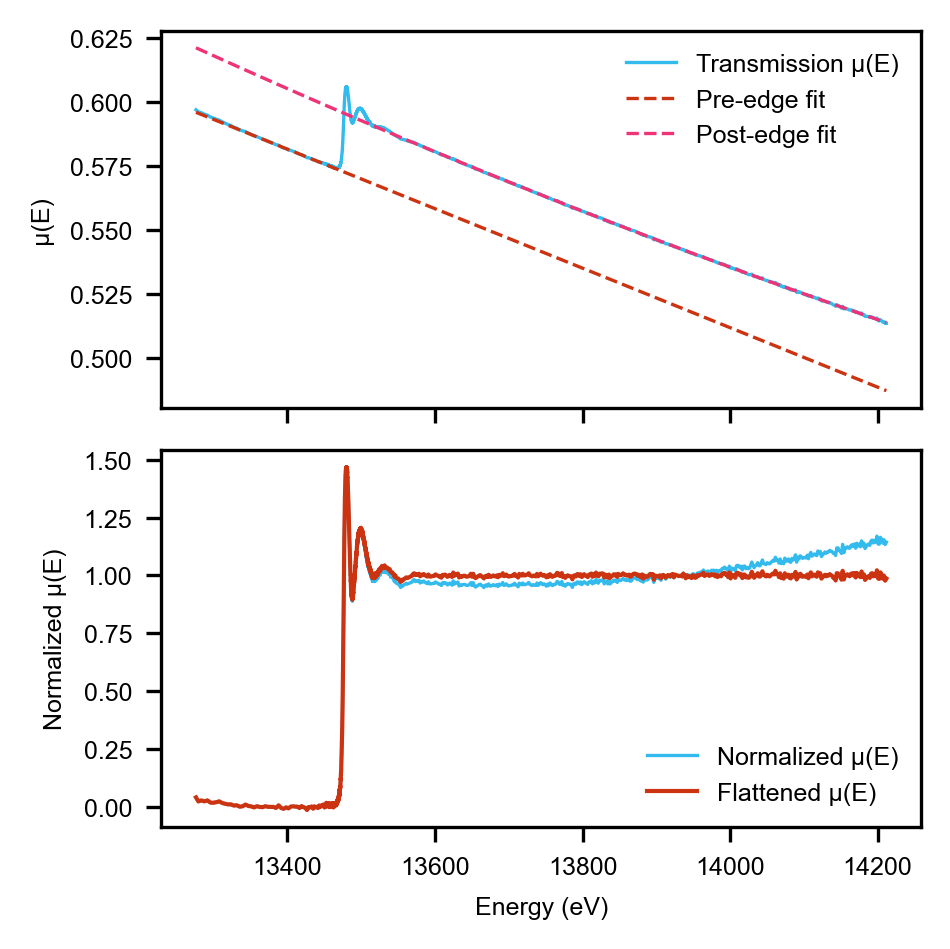

scan = 84743
e0 = 13470.00 eV
edge step = 0.022963


In [4]:
# Data flattening and visualisation for a single scan
scan_num = 84743
scanData = getSlewData(scan_num, subsetDf)

larch_out = flatten_transmission_frame(
    scanData,
    e0=13470,
    pre1=-90,
    pre2=-50,
    norm1=210,
    norm2=730,
    nnorm=2,
    name=f"scan_{scan_num}",
)

larch_df = pd.DataFrame({
    'energy_eV': larch_out['energy'],
    'mu_trans': larch_out['mu'],
    'mu_norm': larch_out['norm'],
    'mu_flat': larch_out['flat'],
})

fig, axes = plt.subplots(2, 1, figsize=(8*cm, 8*cm), sharex=True)

axes[0].plot(larch_df['energy_eV'], larch_df['mu_trans'], label='Transmission μ(E)', linewidth=0.8)
axes[0].plot(larch_df['energy_eV'], larch_out['pre_edge'], '--', label='Pre-edge fit', linewidth=0.8)
axes[0].plot(larch_df['energy_eV'], larch_out['post_edge'], '--', label='Post-edge fit', linewidth=0.8)
axes[0].set_ylabel('μ(E)')
axes[0].legend(frameon=False)

axes[1].plot(larch_df['energy_eV'], larch_df['mu_norm'], label='Normalized μ(E)', linewidth=0.8)
axes[1].plot(larch_df['energy_eV'], larch_df['mu_flat'], label='Flattened μ(E)', linewidth=1.0)
axes[1].set_xlabel('Energy (eV)')
axes[1].set_ylabel('Normalized μ(E)')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"scan = {scan_num}")
print(f"e0 = {larch_out['e0']:.2f} eV")
print(f"edge step = {larch_out['edge_step']:.6f}")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

def read_one_scan_with_info(scan_num, metadata_file, raw_dir):
    meta_df = pd.read_csv(metadata_file, sep="\t")
    row = meta_df.loc[meta_df["scan_number"] == scan_num].iloc[0]

    mda_path = Path(raw_dir) / f"MEX1_{scan_num}.mda"
    metadata, dim1, dim2 = mda.readMDA(mda_path)

    return {
        "scan_number": scan_num,
        "timestamp": row["timestamp"],
        "comment1": row["MEX1SSCAN01:saveData_comment1"],
        "energy_eV": np.asarray(dim2.d[0].data, dtype=float).reshape(-1) * 1000,
        "i0": np.asarray(dim2.d[2].data, dtype=float).reshape(-1),
        "i1": np.asarray(dim2.d[3].data, dtype=float).reshape(-1),
        "fluor_sum": sum(
            np.asarray(dim2.d[i].data, dtype=float).reshape(-1)
            for i in [16, 17, 18, 19]
        ),
    }

scan = read_one_scan_with_info(
    84743,
    "/media/Computation_bkp/Haoyu_MEX_XAS_20260327/xas_raw_data_20260327/25436.metadata",
    "/media/Computation_bkp/Haoyu_MEX_XAS_20260327/xas_raw_data_20260327",
)

print(scan["timestamp"])
print(scan["comment1"])

2026.03.26 13:27:33 Thu
Br_MGM_1.5_10mM_KBr_Full_CA_20runs


available scans: [85028, 85029, 85030, 85031, 85032, 85033, 85034, 85035, 85036, 85037, 85038, 85039, 85040, 85041, 85042, 85043]
skipped scans: []


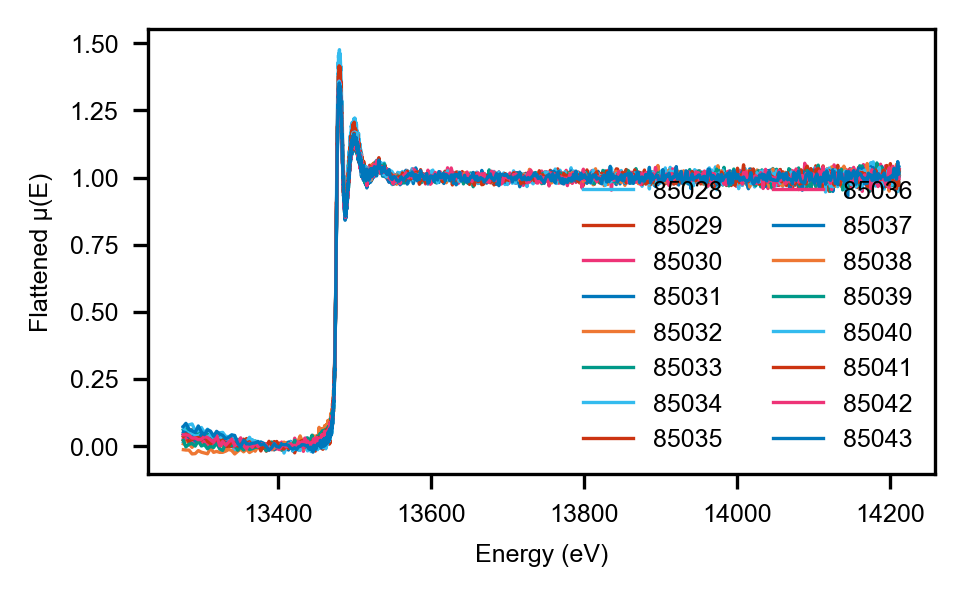

In [ ]:
# Plot raw transmission spectrum for an electric potential
requested_scan_nums = np.concatenate([np.arange(85028, 85044), ])
available_scan_nums = [int(scan_num) for scan_num in requested_scan_nums if int(scan_num) in subsetDf.index]
skipped_scan_nums = [int(scan_num) for scan_num in requested_scan_nums if int(scan_num) not in subsetDf.index]

print('available scans:', available_scan_nums)
print('skipped scans:', skipped_scan_nums)

flat_scans = {}

for scan_num in available_scan_nums:
    scanData = getSlewData(scan_num, subsetDf)
    flat_scans[scan_num] = flatten_transmission_frame(
        scanData,
        e0=13470,
        pre1=-90,
        pre2=-50,
        norm1=210,
        norm2=730,
        nnorm=2,
        name=f"scan_{scan_num}",
    )

fig, ax = plt.subplots(figsize=(8*cm, 5*cm))

for scan_num, out in flat_scans.items():
    ax.plot(out['energy'], out['flat'], label=f"{scan_num}", linewidth=0.8)

# ax.set_xlim(13500, 14300)
# ax.set_ylim(0.9, 1.15)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Flattened μ(E)')
ax.legend(frameon=False, ncol=2, fontsize=6)
plt.tight_layout()
plt.show()


## Plot converted EXAFS

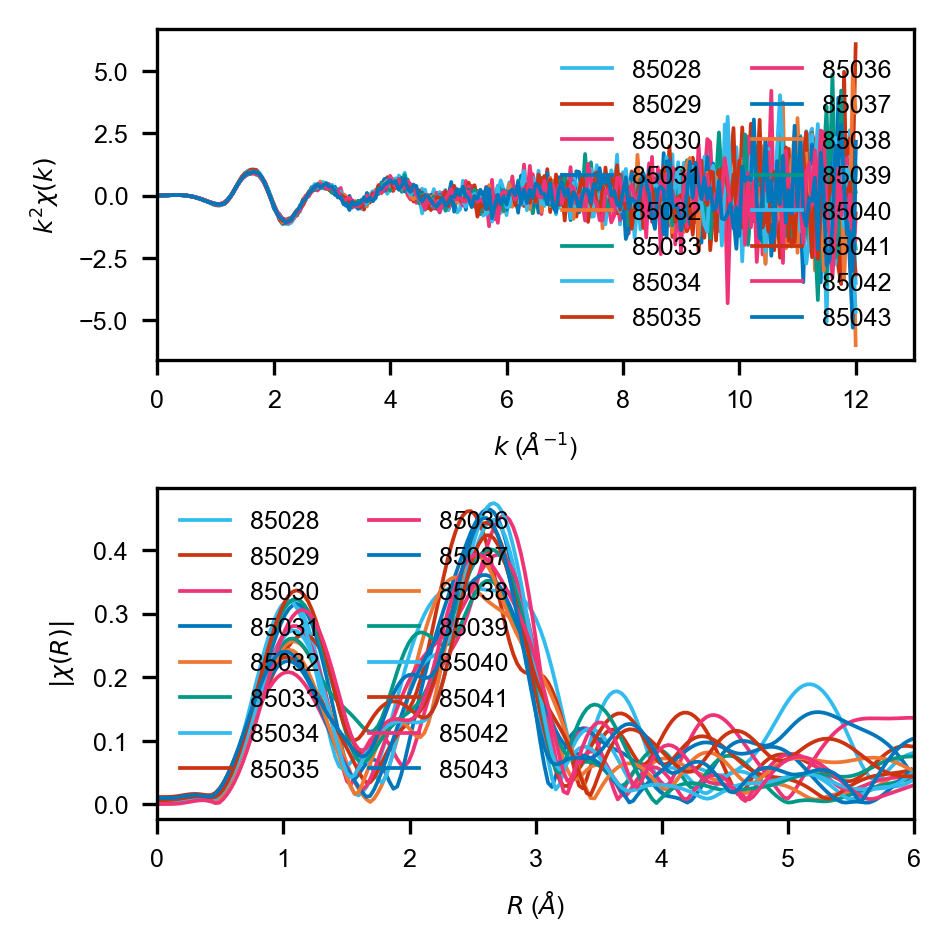

In [5]:
exafs_scans = {}

for scan_num in available_scan_nums:
    scanData = getSlewData(scan_num, subsetDf)
    exafs_scans[scan_num] = extract_exafs_transmission_frame(
        scanData,
        e0=13470,
        pre1=-90,
        pre2=-50,
        norm1=210,
        norm2=730,
        nnorm=2,
        rbkg=1.0,
        bkg_kmin=0,
        bkg_kmax=12,
        ft_kmin=2,
        ft_kmax=8,
        ft_kweight=2,
        ft_dk=2,
        ft_window='kaiser',
        rmax_out=6.0,
        name=f"scan_{scan_num}",
    )

summary_rows = []
for scan_num, out in exafs_scans.items():
    summary_rows.append({
        'scan': scan_num,
        'e0_eV': out['e0'],
        'edge_step': out['edge_step'],
        'k_max': np.nanmax(out['k']),
    })

# display(pd.DataFrame(summary_rows))

fig, axes = plt.subplots(2, 1, figsize=(8*cm, 8*cm), sharex=False)

for scan_num, out in exafs_scans.items():
    axes[0].plot(out['k'], out['chi_kw'], label=f"{scan_num}", linewidth=0.9)
    axes[1].plot(out['r'], out['chir_mag'], label=f"{scan_num}", linewidth=0.9)

axes[0].set_xlim(0, 13)
axes[0].set_xlabel(r'$k$ ($\AA^{-1}$)')
axes[0].set_ylabel(r'$k^2\chi(k)$')
axes[0].legend(frameon=False, ncol=2, fontsize=6)

axes[1].set_xlim(0, 6)
axes[1].set_xlabel(r'$R$ ($\AA$)')
axes[1].set_ylabel(r'$|\chi(R)|$')
axes[1].legend(frameon=False, ncol=2, fontsize=6)

plt.tight_layout()
plt.show()

## Convergence test for an electric potential data

first N with rel_rms_k < 5%: 16
first N with rel_rms_r < 5%: 5


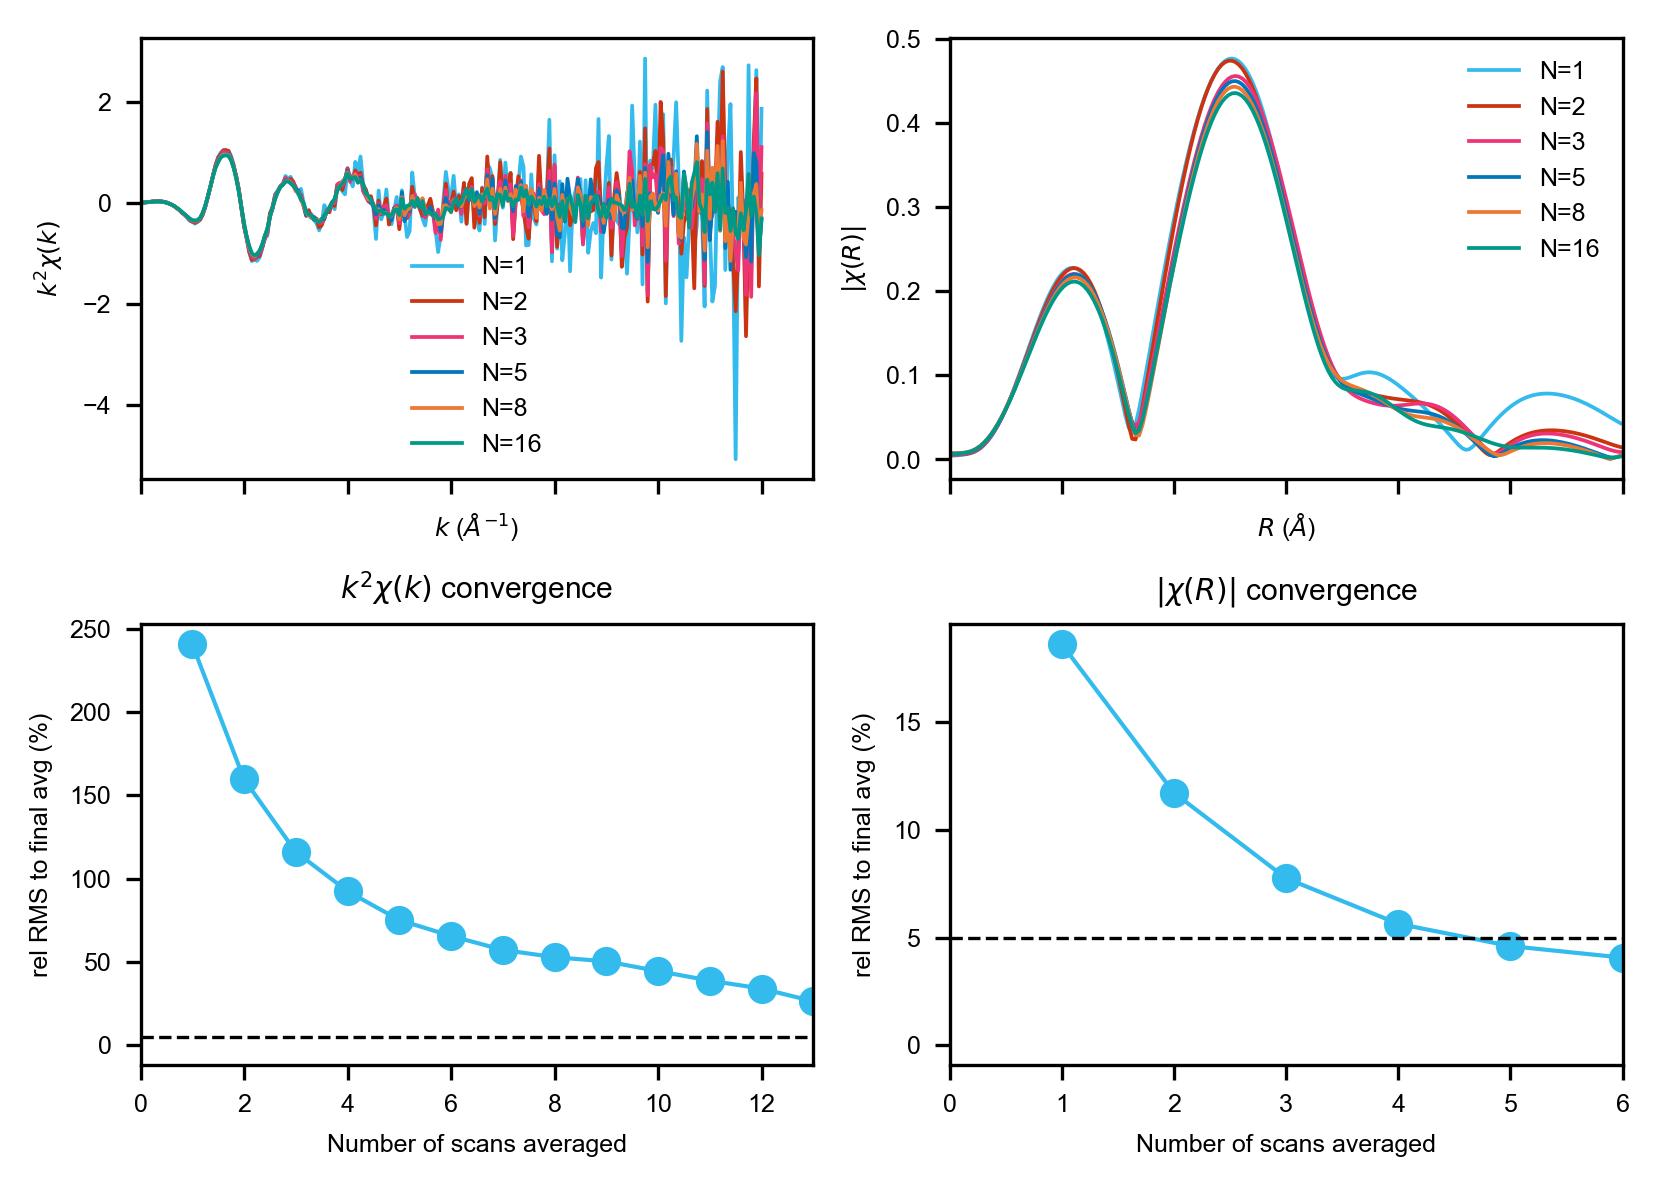

In [ ]:
scan_order = list(available_scan_nums)
common_k = exafs_scans[scan_order[0]]['k']

chi_stack = np.vstack([
    np.interp(common_k, exafs_scans[scan_num]['k'], exafs_scans[scan_num]['chi'])
    for scan_num in scan_order
])

ft_kmin = 2
ft_kmax = 5
ft_kweight = 2
ft_dk = 2
ft_window = 'kaiser'
rmax_out = 6.0

cumulative_results = []

for n_scans in range(1, len(scan_order) + 1):
    avg_chi = np.mean(chi_stack[:n_scans], axis=0)
    avg_group = Group(name=f'avg_{n_scans}', k=common_k, chi=avg_chi)
    xftf(
        avg_group.k,
        avg_group.chi,
        group=avg_group,
        kmin=ft_kmin,
        kmax=ft_kmax,
        kweight=ft_kweight,
        dk=ft_dk,
        window=ft_window,
        rmax_out=rmax_out,
    )
    cumulative_results.append({
        'n_scans': n_scans,
        'last_scan': scan_order[n_scans - 1],
        'k': avg_group.k.copy(),
        'chi_kw': avg_group.chi * np.power(avg_group.k, ft_kweight),
        'r': avg_group.r.copy(),
        'chir_mag': avg_group.chir_mag.copy(),
    })

reference_result = cumulative_results[-1]
reference_chi_scale = np.sqrt(np.mean(reference_result['chi_kw'] ** 2))
reference_r_scale = np.sqrt(np.mean(reference_result['chir_mag'] ** 2))

convergence_rows = []
for result in cumulative_results:
    rel_rms_k = np.sqrt(np.mean((result['chi_kw'] - reference_result['chi_kw']) ** 2)) / reference_chi_scale
    rel_rms_r = np.sqrt(np.mean((result['chir_mag'] - reference_result['chir_mag']) ** 2)) / reference_r_scale
    convergence_rows.append({
        'n_scans': result['n_scans'],
        'last_scan': result['last_scan'],
        'rel_rms_k_pct': 100 * rel_rms_k,
        'rel_rms_r_pct': 100 * rel_rms_r,
    })

convergence_df = pd.DataFrame(convergence_rows)
# display(convergence_df)

k_threshold = next((int(row['n_scans']) for _, row in convergence_df.iterrows() if row['rel_rms_k_pct'] < 5), None)
r_threshold = next((int(row['n_scans']) for _, row in convergence_df.iterrows() if row['rel_rms_r_pct'] < 5), None)
print(f'first N with rel_rms_k < 5%: {k_threshold}')
print(f'first N with rel_rms_r < 5%: {r_threshold}')

selected_ns = [result['n_scans'] for result in cumulative_results]
if len(selected_ns) > 8:
    selected_ns = sorted(set([1, 2, 3, 5, len(cumulative_results) // 2, len(cumulative_results)]))

fig, axes = plt.subplots(2, 2, figsize=(14*cm, 10*cm), sharex='col')

for result in cumulative_results:
    #  in (5, 11, 23)  
    if result['n_scans'] in selected_ns: 
        label = f"N={result['n_scans']}"
        axes[0, 0].plot(result['k'], result['chi_kw'], linewidth=0.9, label=label)
        axes[0, 1].plot(result['r'], result['chir_mag'], linewidth=0.9, label=label)

axes[0, 0].set_xlim(0, 13)
axes[0, 0].set_xlabel(r'$k$ ($\AA^{-1}$)')
axes[0, 0].set_ylabel(r'$k^2\chi(k)$')
axes[0, 0].legend(frameon=False, fontsize=6)

axes[0, 1].set_xlim(0, 6)
axes[0, 1].set_xlabel(r'$R$ ($\AA$)')
axes[0, 1].set_ylabel(r'$|\chi(R)|$')
axes[0, 1].legend(frameon=False, fontsize=6)

axes[1, 0].plot(convergence_df['n_scans'], convergence_df['rel_rms_k_pct'], marker='o', linewidth=1.0)
axes[1, 0].axhline(5, color='k', linestyle='--', linewidth=0.8)
axes[1, 0].set_xlabel('Number of scans averaged')
axes[1, 0].set_ylabel('rel RMS to final avg (%)')
axes[1, 0].set_title(r'$k^2\chi(k)$ convergence')

axes[1, 1].plot(convergence_df['n_scans'], convergence_df['rel_rms_r_pct'], marker='o', linewidth=1.0)
axes[1, 1].axhline(5, color='k', linestyle='--', linewidth=0.8)
axes[1, 1].set_xlabel('Number of scans averaged')
axes[1, 1].set_ylabel('rel RMS to final avg (%)')
axes[1, 1].set_title(r'$|\chi(R)|$ convergence')

plt.tight_layout()
plt.show()

# Plot EXAFS spectrum for various electric potential

In [ ]:


def average_exafs_scans_in_range(range_start, range_stop, label, ax):
    curve_label = f'{range_start}-{range_stop - 1}'

    requested_scan_nums = list(range(range_start, range_stop))
    range_scan_nums = [scan_num for scan_num in requested_scan_nums if scan_num in subsetDf.index]
    skipped_scan_nums = [scan_num for scan_num in requested_scan_nums if scan_num not in subsetDf.index]

    if len(range_scan_nums) == 0:
        raise ValueError('No valid scans in the requested range.')

    exafs_scans = {}
    for scan_num in range_scan_nums:
        if scan_num not in exafs_scans:
            scanData = getSlewData(scan_num, subsetDf)
            exafs_scans[scan_num] = extract_exafs_transmission_frame(
                scanData,
                e0=13470,
                pre1=-90,
                pre2=-50,
                norm1=210,
                norm2=730,
                nnorm=2,
                rbkg=1.0,
                bkg_kmin=0,
                bkg_kmax=12,
                ft_kmin=2,
                ft_kmax=6.5,
                ft_kweight=2,
                ft_dk=2,
                ft_window='kaiser',
                rmax_out=6.0,
                name=f'scan_{scan_num}',
            )

    common_k = exafs_scans[range_scan_nums[0]]['k']
    chi_stack = np.vstack([
        np.interp(common_k, exafs_scans[scan_num]['k'], exafs_scans[scan_num]['chi'])
        for scan_num in range_scan_nums
    ])
    avg_chi = np.mean(chi_stack, axis=0)

    avg_group = Group(name=f'avg_{curve_label}', k=common_k, chi=avg_chi)
    xftf(
        avg_group.k,
        avg_group.chi,
        group=avg_group,
        kmin=2,
        kmax=6,
        kweight=2,
        dk=2,
        window='kaiser',
        rmax_out=6.0,
    )

    averaged_xir_curves = {}
    averaged_xir_curves[curve_label] = {
        'label': curve_label,
        'scan_nums': range_scan_nums,
        'skipped_scan_nums': skipped_scan_nums,
        'n_scans': len(range_scan_nums),
        'k': avg_group.k.copy(),
        'chi': avg_group.chi.copy(),
        'chi_kw': avg_group.chi * np.power(avg_group.k, 2),
        'r': avg_group.r.copy(),
        'chir': avg_group.chir.copy(),
        'chir_mag': avg_group.chir_mag.copy(),
        'chir_re': avg_group.chir_re.copy(),
        'chir_im': avg_group.chir_im.copy(),
        'plot_df': pd.DataFrame({
            'r': avg_group.r.copy(),
            'chir_mag': avg_group.chir_mag.copy(),
        }),
    }

    averaged_xir_data = averaged_xir_curves[curve_label]

    # display(pd.DataFrame([{
    #     'label': curve_label,
    #     'n_scans': averaged_xir_data['n_scans'],
    #     'scan_nums': averaged_xir_data['scan_nums'],
    #     'skipped_scan_nums': averaged_xir_data['skipped_scan_nums'],
    # }]))

    # fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
    ax.plot(
        averaged_xir_data['r'],
        averaged_xir_data['chir_mag'],
        linewidth=1.2,
        label=label,
    )
    ax.set_xlim(0, 6)
    ax.set_xlabel(r'$R$ ($\AA$)')
    ax.set_ylabel(r'$|\chi(R)|$')
    # ax.legend(labels=[label], frameon=False)
    # plt.tight_layout()
    # plt.show()

    return averaged_xir_data['r'], averaged_xir_data['chir_mag']


## MGM_1.5 | 10 mM KBr

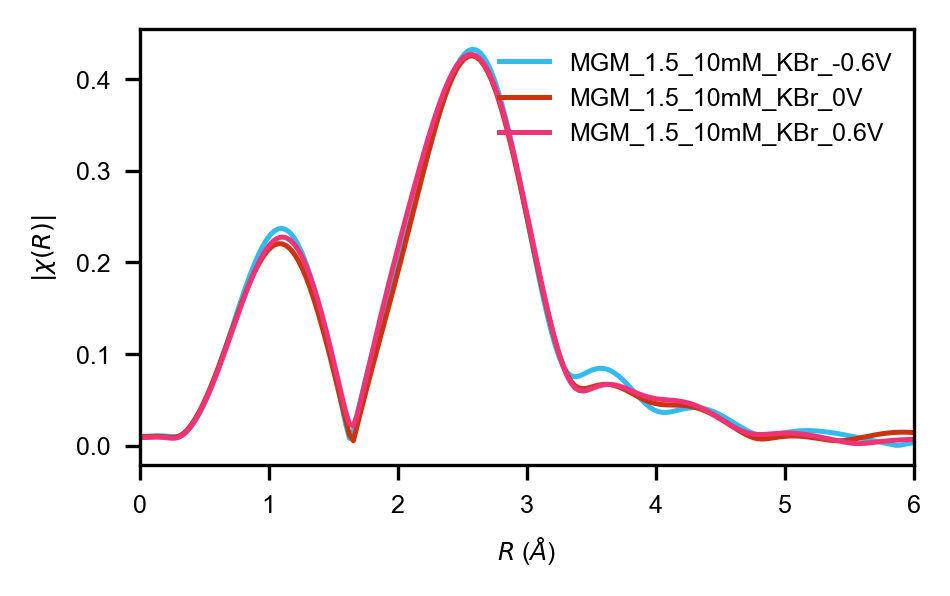

In [37]:
plt_groups = []
range_group = {
            #    "MGM_1.5_10mM_KBr_-0.8V":(84985, 84998),  
               "MGM_1.5_10mM_KBr_-0.6V":(85028, 85044),
               "MGM_1.5_10mM_KBr_0V":(84961, 84975), 
               "MGM_1.5_10mM_KBr_0.6V":(84938, 84950), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## MGM_0.1 | 10 mM KBr

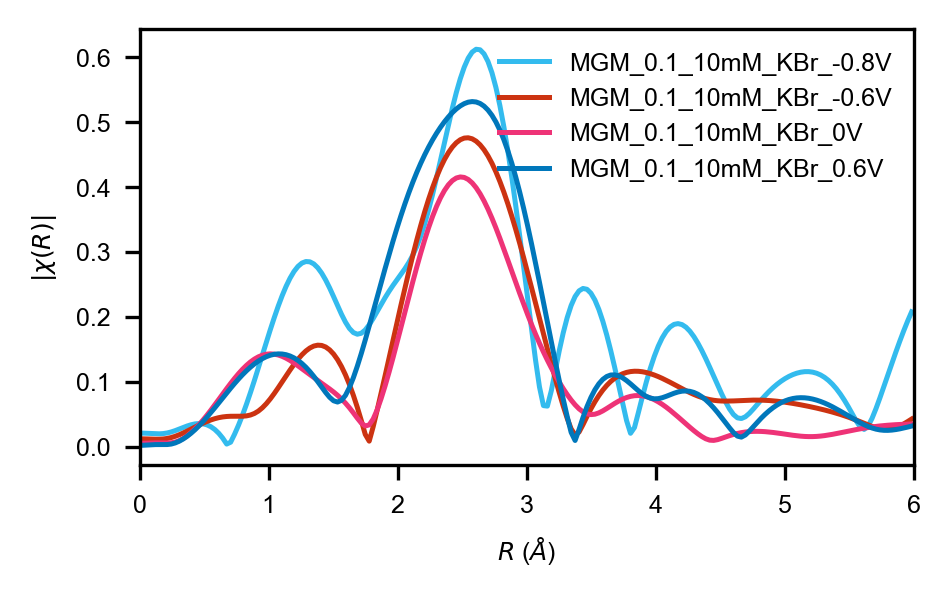

In [38]:
plt_groups = []
range_group = {"MGM_0.1_10mM_KBr_-0.8V":(84560, 84565),
               "MGM_0.1_10mM_KBr_-0.6V":(84555, 84560), 
               "MGM_0.1_10mM_KBr_0V":(84550, 84555), 
               "MGM_0.1_10mM_KBr_0.6V":(84546, 84550), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    # print(f"label: {label}")
    # print(r, chir_mag)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

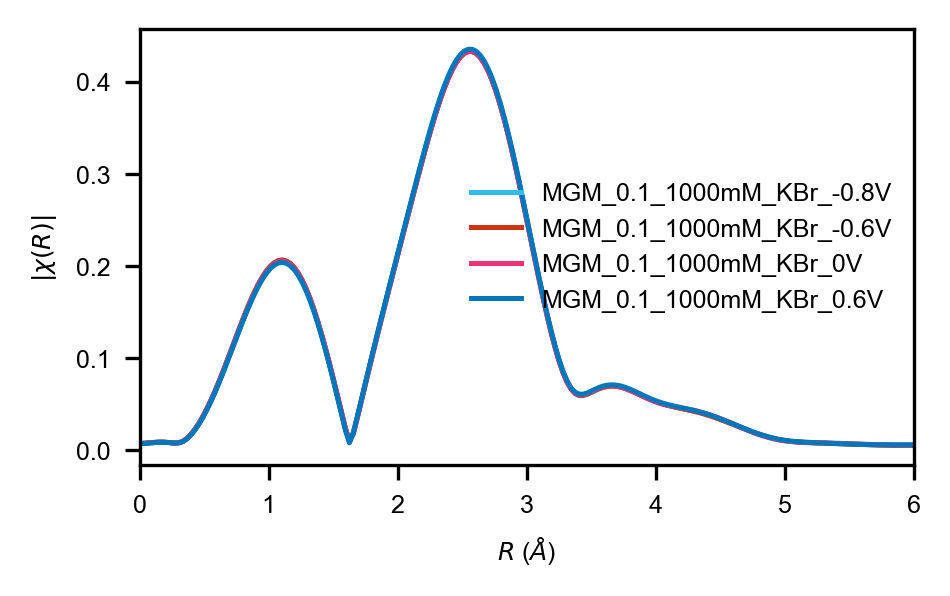

In [ ]:
plt_groups = []
range_group = {"MGM_0.1_1000mM_KBr_-0.8V":(84632, 84636), 
               "MGM_0.1_1000mM_KBr_-0.6V":(84627, 84631), 
               "MGM_0.1_1000mM_KBr_0V":(84622, 84626), 
               "MGM_0.1_1000mM_KBr_0.6V":(84617, 84621), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    # print(f"label: {label}")
    # print(r, chir_mag)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

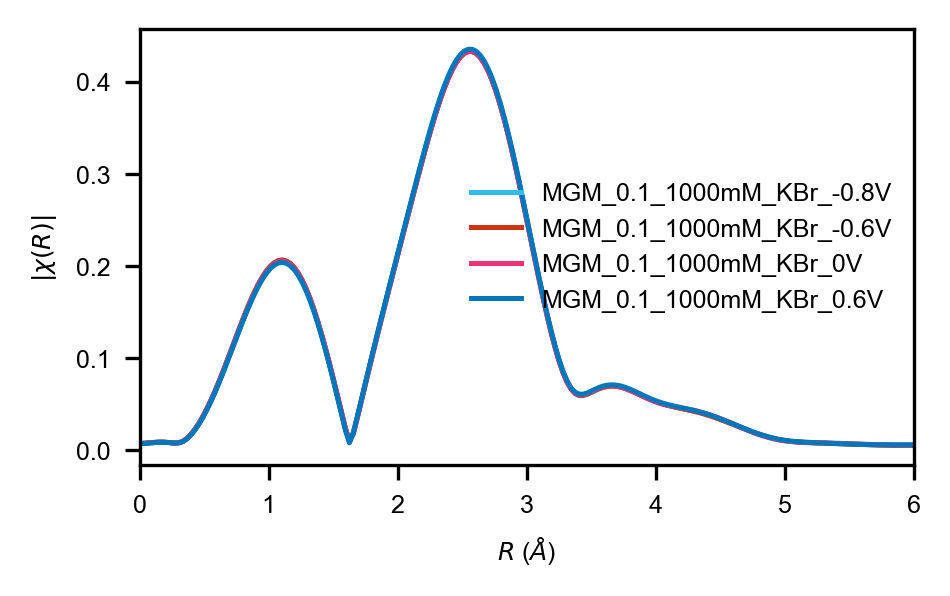

In [ ]:
plt_groups = []
range_group = {"MGM_0.1_1000mM_KBr_-0.8V":(84632, 84636), 
               "MGM_0.1_1000mM_KBr_-0.6V":(84627, 84631), 
               "MGM_0.1_1000mM_KBr_0V":(84622, 84626), 
               "MGM_0.1_1000mM_KBr_0.6V":(84617, 84621), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    # print(f"label: {label}")
    # print(r, chir_mag)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

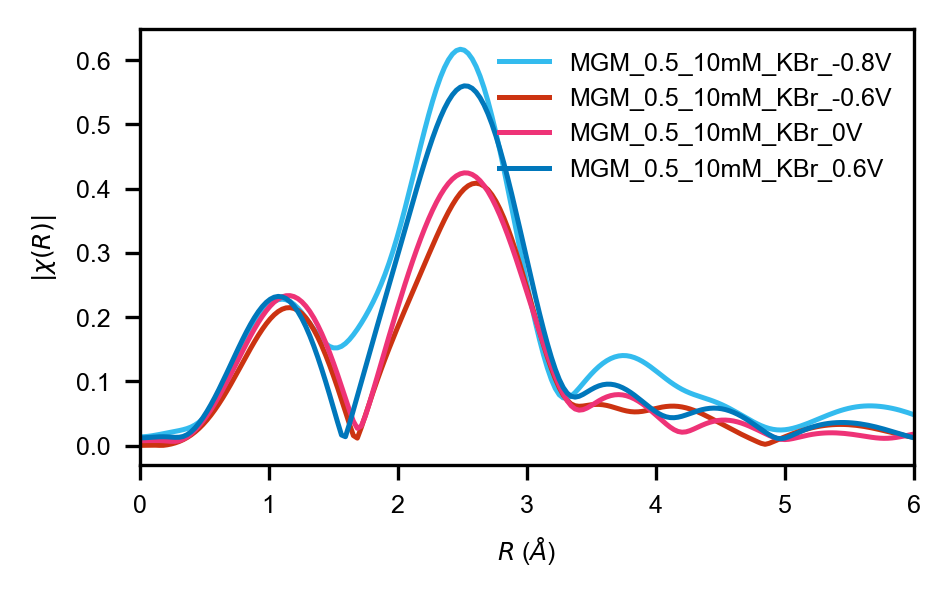

In [169]:
plt_groups = []
range_group = {"MGM_0.5_10mM_KBr_-0.8V":(84611, 84615), 
               "MGM_0.5_10mM_KBr_-0.6V":(84606, 84610), 
               "MGM_0.5_10mM_KBr_0V":(84601, 84605), 
               "MGM_0.5_10mM_KBr_0.6V":(84596, 84600), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    # print(f"label: {label}")
    # print(r, chir_mag)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

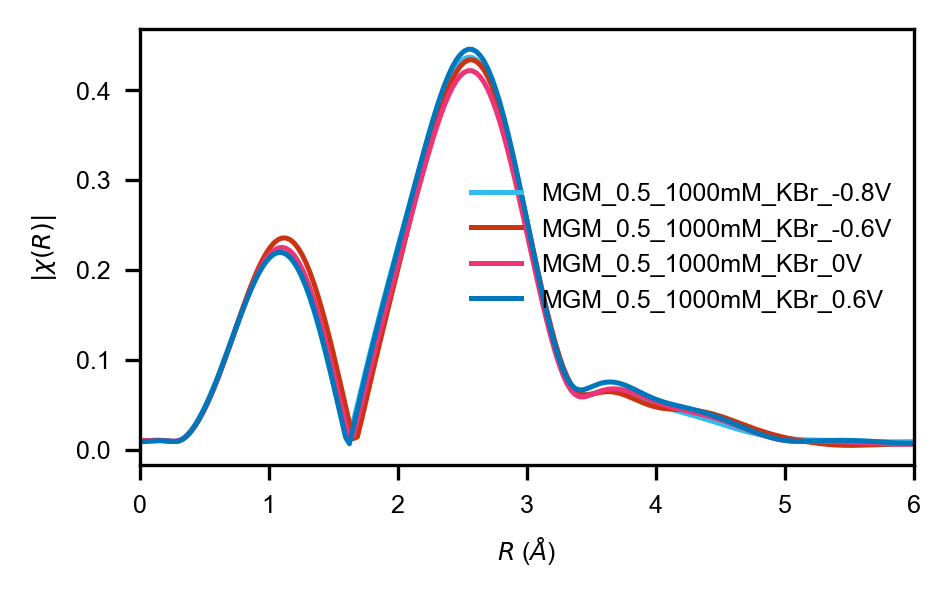

In [171]:
plt_groups = []
range_group = {"MGM_0.5_1000mM_KBr_-0.8V":(84715, 84720), 
               "MGM_0.5_1000mM_KBr_-0.6V":(84710, 84714), 
               "MGM_0.5_1000mM_KBr_0V":(84705, 84709), 
               "MGM_0.5_1000mM_KBr_0.6V":(84700, 84704), 
               }
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for label, num_range in range_group.items():
    r, chir_mag = average_exafs_scans_in_range(*num_range, label=label, ax=ax)
    # print(f"label: {label}")
    # print(r, chir_mag)
    plt_groups.append((r, chir_mag))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()